The objective of this task is to build a binary classification model that predicts whether a borrower will experience serious financial distress within two years. Logistic Regression is used because it provides probability-based predictions and interpretable feature coefficients, which are useful in credit risk modelling. The model is evaluated using classification metrics such as Accuracy, Precision, Recall, F1-score, and AUC-ROC.


   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

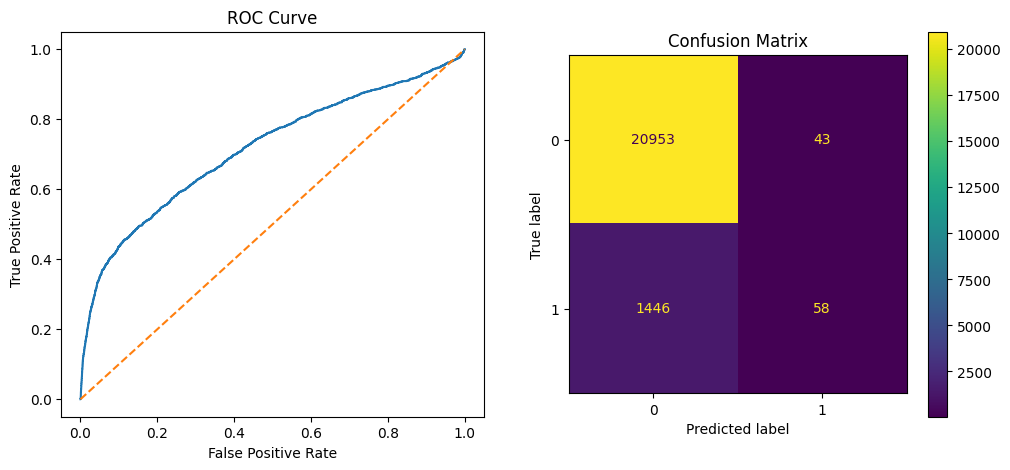

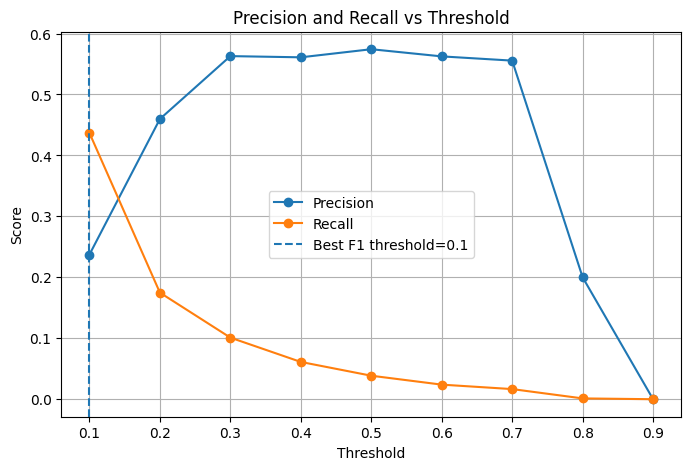

Best Threshold: 0.1
Maximum F1: 0.30758426966292135
The features with the largest absolute coefficients have the strongest influence on the credit default prediction.
Positive coefficients indicate that an increase in that feature increases the probability of financial distress, while negative coefficients reduce the predicted risk.
Features related to repayment history and debt burden are expected to have strong influence because they directly reflect borrower financial stability.
The coefficient magnitudes show which financial indicators are most important for predicting default risk.


In [4]:
# Question 1.1: Logistic Regression for Credit Default Prediction

print("The objective of this task is to build a binary classification model that predicts whether a borrower will experience serious financial distress within two years. Logistic Regression is used because it provides probability-based predictions and interpretable feature coefficients, which are useful in credit risk modelling. The model is evaluated using classification metrics such as Accuracy, Precision, Recall, F1-score, and AUC-ROC.")

#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#1. Load dataset
df = pd.read_csv("1.1/cs-training.csv")
print(df.head())

#Remove unnecessary columns
df.drop(columns=["Unnamed: 0"],inplace=True)
df.head()
df.shape
df.isnull().sum() #Check missing values

#2(a). Median Imputation
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(df["NumberOfDependents"].median())
df.isnull().sum()

#Separate Features and Target
X = df.drop(columns=["SeriousDlqin2yrs"])
y = df["SeriousDlqin2yrs"]
y.value_counts()

#2(b). Stratified 70/15/15 Train Validation Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.30,stratify=y,random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.50,stratify=y_temp,random_state=42)
print("X_train.shape:",X_train.shape)
print("X_val.shape:",X_val.shape)
print("X_test.shape:",X_test.shape)

#2(c). Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#3. Train Logistic Regression
model = LogisticRegression(solver="lbfgs",max_iter=1000,random_state=42)
model.fit(X_train_scaled,y_train)
#Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

#Evaluation Metrics Table
metrics_table = pd.DataFrame({
        "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC-ROC"
    ],
        "Value":[
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred),
        roc_auc_score(y_test,y_prob)
    ]
})
print("Metrics Table")
print(metrics_table)

#4. ROC Curve and Confusion Matrix
fig, ax = plt.subplots(1,2,figsize=(12,5))
# ROC Curve
fpr,tpr,_ = roc_curve(y_test,y_prob)
ax[0].plot(fpr,tpr)
ax[0].plot([0,1],[0,1],linestyle="--")
ax[0].set_title("ROC Curve")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")

# Confusion Matrix
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(ax=ax[1])
ax[1].set_title("Confusion Matrix")
plt.show()

#5. Threshold Analysis
thresholds = np.arange(0.1,1.0,0.1)
precision_values=[]
recall_values=[]
f1_values=[]
for t in thresholds:
    pred_threshold = (y_prob >= t).astype(int)
    precision_values.append(precision_score(y_test,pred_threshold))
    recall_values.append(recall_score(y_test,pred_threshold))
    f1_values.append(f1_score(y_test,pred_threshold))

plt.figure(figsize=(8,5))
plt.plot(thresholds,precision_values,marker="o",label="Precision")
plt.plot(thresholds,recall_values,marker="o",label="Recall")
best_threshold = thresholds[np.argmax(f1_values)]
plt.axvline(best_threshold,linestyle="--",label=f"Best F1 threshold={best_threshold}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.legend()
plt.grid()
plt.show()

print("Best Threshold:",best_threshold)
print("Maximum F1:",max(f1_values))

#6. Coefficient Interpretation
coefficients = pd.DataFrame({"Feature":X.columns,"Coefficient":model.coef_[0],"Absolute":abs(model.coef_[0])})
coefficients.sort_values(by="Absolute",ascending=False).head(5)

print("The features with the largest absolute coefficients have the strongest influence on the credit default prediction.")
print("Positive coefficients indicate that an increase in that feature increases the probability of financial distress, while negative coefficients reduce the predicted risk.") 
print("Features related to repayment history and debt burden are expected to have strong influence because they directly reflect borrower financial stability.") 
print("The coefficient magnitudes show which financial indicators are most important for predicting default risk.")

The objective of this task is to study decision tree behaviour and understand how controlling tree complexity affects model performance. A decision tree can easily overfit by creating very deep branches that memorize training data. Therefore, different tree depths and cost-complexity pruning are tested to find a model that generalizes well on unseen data.
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
(303, 14)
<class 'panda

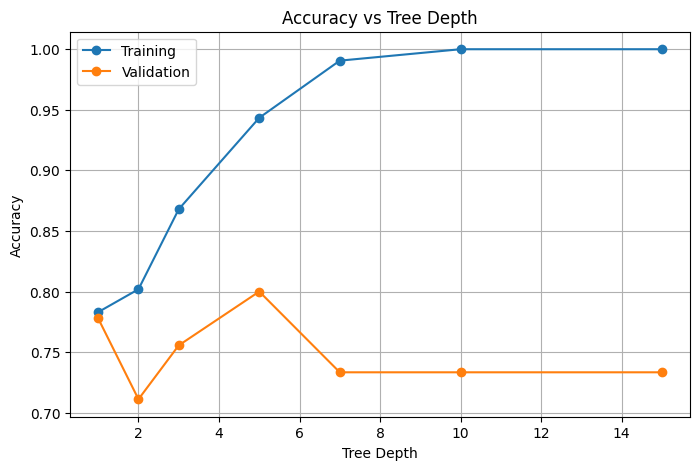

Best Depth: 5
AUC: 0.6514285714285714
F1: 0.6923076923076923
Best Alpha: 0.011320754716981131
Pruned Tree AUC: 0.680952380952381
Pruned Tree F1: 0.7719298245614035


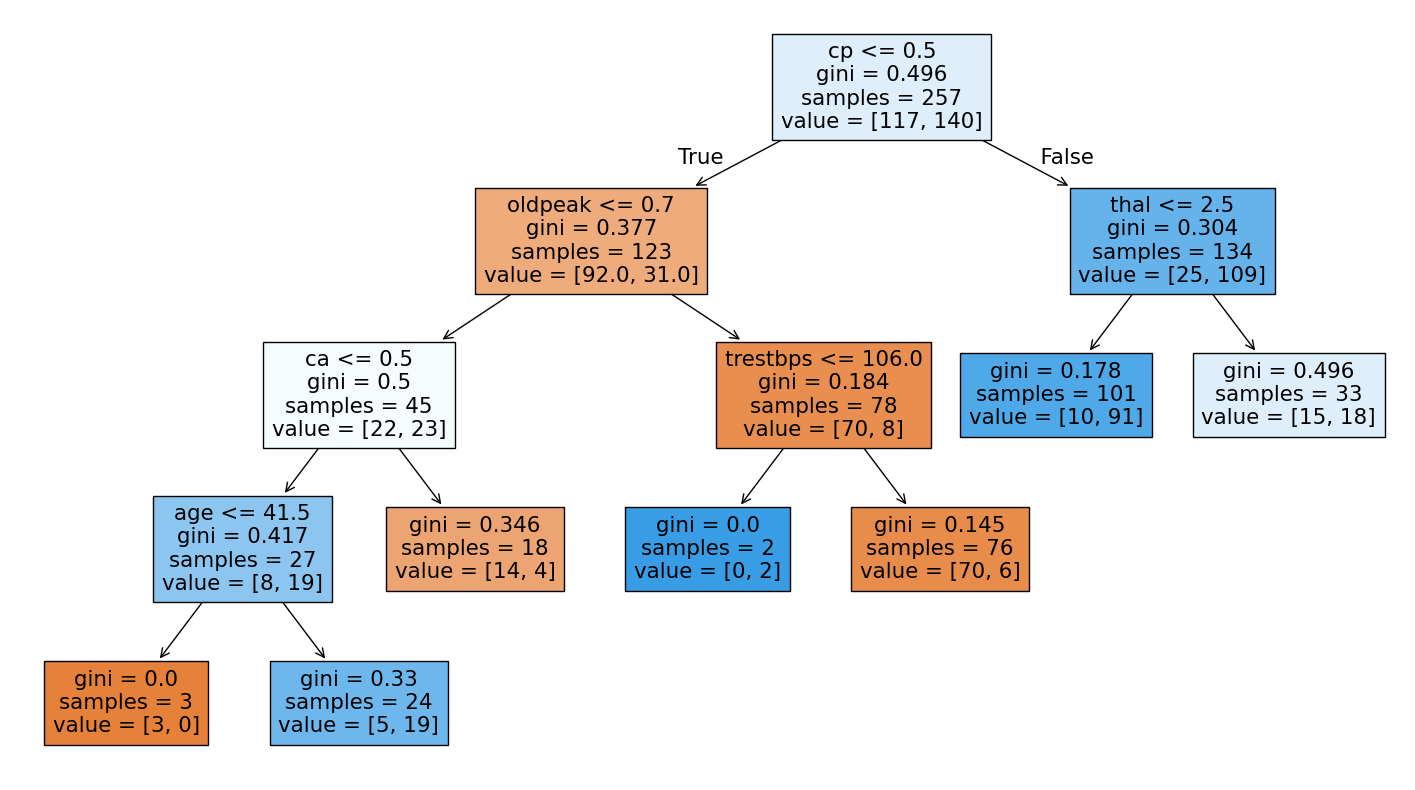

Comparison Table
                Model       AUC        F1  Depth
0       Unpruned Tree  0.713333  0.745098      8
1  Depth Limited Tree  0.651429  0.692308      5
2         Pruned Tree  0.680952  0.771930      4
The fully grown decision tree achieved very high training performance but showed signs of overfitting because its test performance was lower.
Limiting tree depth reduced model complexity and improved generalization by preventing excessive branching.
Cost-complexity pruning further reduced unnecessary branches and produced a more balanced model.
The pruned tree provides a better trade-off between bias and variance compared with the unpruned model.


In [13]:
# Question 1.2: Decision Tree Classifier with Pruning

print("The objective of this task is to study decision tree behaviour and understand how controlling tree complexity affects model performance. A decision tree can easily overfit by creating very deep branches that memorize training data. Therefore, different tree depths and cost-complexity pruning are tested to find a model that generalizes well on unseen data.")

#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.metrics import classification_report

#1. Load Dataset
df = pd.read_csv("1.2/heart.csv")
print(df.head())
print(df.shape)
print(df.info())

#Check missing values
df.isnull().sum()
df.isnull().sum()

#Separate Features and Target
X = df.drop(columns=["target"])
y = df["target"]

#2. Train Validation Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.30,stratify=y,random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.50,stratify=y_temp,random_state=42)
print("X_train.shape:",X_train.shape)
print("X_val.shape:",X_val.shape)
print("X_test.shape:",X_test.shape)

#3. Train Fully Grown Decision Tree
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train,y_train)
train_pred = tree_full.predict(X_train)
test_pred = tree_full.predict(X_test)
print("Training Accuracy:",accuracy_score(y_train,train_pred))
print("Testing Accuracy:",accuracy_score(y_test,test_pred))

#4. Depth Limited Trees
depth_values = [1,2,3,5,7,10,15,None]
train_scores = []
val_scores = []

for i in depth_values:
    model = DecisionTreeClassifier(max_depth=i,random_state=42)
    model.fit(X_train,y_train)
    train_accuracy = accuracy_score(y_train,model.predict(X_train))
    val_accuracy = accuracy_score(y_val,model.predict(X_val))
    train_scores.append(train_accuracy)
    val_scores.append(val_accuracy)
depth_results = pd.DataFrame({"Depth":depth_values,"Training Accuracy":train_scores,"Validation Accuracy":val_scores})
print("Depth_resuts")
print(depth_results)

# Accuracy vs Depth Plot
plt.figure(figsize=(8,5))
plt.plot(depth_values[:-1],train_scores[:-1],marker="o",label="Training")
plt.plot(depth_values[:-1],val_scores[:-1],marker="o",label="Validation")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Depth")
plt.legend()
plt.grid()
plt.show()

best_depth = depth_values[np.argmax(val_scores)]
print("Best Depth:",best_depth)

#5. Retrain Best Depth Model
X_train_full = pd.concat([X_train,X_val])
y_train_full = pd.concat([y_train,y_val])

best_tree = DecisionTreeClassifier(max_depth=best_depth,random_state=42)
best_tree.fit(X_train_full,y_train_full)
test_prob = best_tree.predict_proba(X_test)[:,1]
print("AUC:",roc_auc_score(y_test,test_prob))
print("F1:",f1_score(y_test,best_tree.predict(X_test)))

#6. Cost Complexity Pruning
initial_tree = DecisionTreeClassifier(random_state=42)
initial_tree.fit(X_train,y_train)
path = initial_tree.cost_complexity_pruning_path(X_train,y_train)
alphas = path.ccp_alphas
alpha_scores = []
for i in alphas:
    model = DecisionTreeClassifier(ccp_alpha=i,random_state=42)
    model.fit(X_train,y_train)
    score = roc_auc_score(y_val,model.predict_proba(X_val)[:,1])
    alpha_scores.append(score)

best_alpha = alphas[np.argmax(alpha_scores)]
print("Best Alpha:",best_alpha)

#7. Train Pruned Tree
pruned_tree = DecisionTreeClassifier(ccp_alpha=best_alpha,random_state=42)
pruned_tree.fit(X_train_full,y_train_full)
pruned_prob = pruned_tree.predict_proba(X_test)[:,1]
pruned_pred = pruned_tree.predict(X_test)
print("Pruned Tree AUC:",roc_auc_score(y_test,pruned_prob))
print("Pruned Tree F1:",f1_score(y_test,pruned_pred))

#Visualize Final Tree
plt.figure(figsize=(18,10))
plot_tree(pruned_tree,max_depth=4,filled=True,feature_names=X.columns)
plt.show()

#Final Comparison Table
comparison = pd.DataFrame({"Model":["Unpruned Tree","Depth Limited Tree","Pruned Tree"],"AUC":[roc_auc_score(y_test,tree_full.predict_proba(X_test)[:,1]),roc_auc_score(y_test,best_tree.predict_proba(X_test)[:,1]),roc_auc_score(y_test,pruned_tree.predict_proba(X_test)[:,1])],"F1":[f1_score(y_test,tree_full.predict(X_test)),f1_score(y_test, best_tree.predict(X_test)),f1_score(y_test,pruned_tree.predict(X_test))],"Depth":[tree_full.get_depth(),best_tree.get_depth(),pruned_tree.get_depth()]})
print("Comparison Table")
print(comparison)

#8. Report Interpretation Template
print("The fully grown decision tree achieved very high training performance but showed signs of overfitting because its test performance was lower.")
print("Limiting tree depth reduced model complexity and improved generalization by preventing excessive branching.")
print("Cost-complexity pruning further reduced unnecessary branches and produced a more balanced model.")
print("The pruned tree provides a better trade-off between bias and variance compared with the unpruned model.")

The objective of this task is to predict house prices using regularized regression models. Ridge, Lasso, and Elastic Net regression are compared to understand how different regularization techniques control model complexity and improve generalization. The target variable is log-transformed because house prices are usually highly skewed.


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 75493087680.56204, tolerance: 537415025.1745832
  model = cd_fast.sparse_enet_coordinate_descent(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 61136426803.08389, tolerance: 572016182.2224231
  model = cd_fast.sparse_enet_coordinate_descent(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 93189686413.4225, tolerance: 525605188.80204767
  model = cd_fast.sparse_enet_coordinate_desc

Best Parameter through Lasso Regression: {'model__alpha': 0.1}


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 187999094786.7317, tolerance: 537415025.1745832
  model = cd_fast.sparse_enet_coordinate_descent(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 161708277680.6049, tolerance: 572016182.2224231
  model = cd_fast.sparse_enet_coordinate_descent(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 171536009497.98285, tolerance: 525605188.80204767
  model = cd_fast.sparse_enet_coordinate_de

Best Parameter through Elastic Net Regression: {'model__alpha': 0.01, 'model__l1_ratio': 0.2}
Results_df
         Model          RMSE        R2
0        Ridge  30527.319985  0.878504
1        Lasso  28409.771527  0.894774
2  Elastic Net  30488.221652  0.878815
Non-zero coefficients: 249
Total coefficients: 265


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 98126238065.25128, tolerance: 696659484.3571944
  model = cd_fast.sparse_enet_coordinate_descent(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 98126296781.06613, tolerance: 696659484.3571944
  model = cd_fast.sparse_enet_coordinate_descent(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 98120909428.80997, tolerance: 696659484.3571944
  model = cd_fast.sparse_enet_coordinate_desc

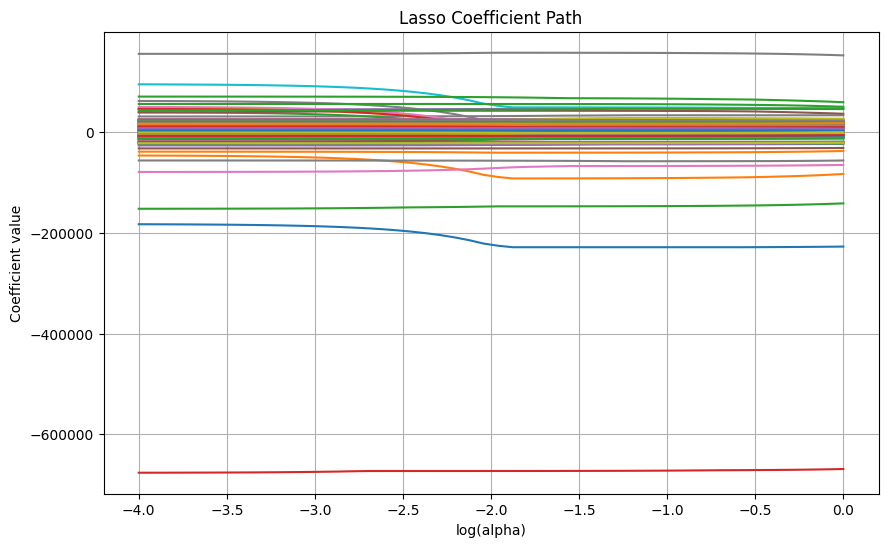

Final Table
         Model                                     Best Lambda          RMSE  \
0        Ridge                            {'model__alpha': 10}  30527.319985   
1        Lasso                           {'model__alpha': 0.1}  28409.771527   
2  Elastic Net  {'model__alpha': 0.01, 'model__l1_ratio': 0.2}  30488.221652   

         R2  
0  0.878504  
1  0.894774  
2  0.878815  
Ridge, Lasso, and Elastic Net regression were evaluated for predicting house prices after applying log transformation to the target variable.
Ridge regression reduces coefficient magnitude and improves stability when features are correlated, while Lasso performs feature selection by shrinking some coefficients to zero.
Elastic Net combines both approaches and provides a balance between coefficient shrinkage and feature selection.
The best model was selected based on RMSE and R² performance on unseen test data.


In [6]:
# Question 2.1: Regularized Regression for House Price Prediction

print("The objective of this task is to predict house prices using regularized regression models. Ridge, Lasso, and Elastic Net regression are compared to understand how different regularization techniques control model complexity and improve generalization. The target variable is log-transformed because house prices are usually highly skewed.")

#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (Ridge,Lasso,ElasticNet)
from sklearn.metrics import (mean_squared_error,r2_score)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

#1. Load dataset
df = pd.read_csv("2.1/train.csv")
print(df.head())
print(df.shape)

# Check missing percentage of every feature
missing_percentage = (df.isnull().sum()/len(df)) * 100
missing_percentage.sort_values(ascending=False).head(20)

#2(b)# Columns with more than 40% missing values

columns_to_drop = missing_percentage[missing_percentage > 40].index
print("Dropped Columns:")
print(columns_to_drop)
df = df.drop(columns=columns_to_drop)

#Separate Target and Features
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

#Train Validation Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#2(a) Log Transform Target
y = np.log1p(y)

#2(c) Create Preprocessing Pipeline
numeric_features = X.select_dtypes(include=["int64","float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns
print("Numerical:",len(numeric_features))
print("Categorical:",len(categorical_features))
numeric_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
categorical_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer(transformers=[("num",numeric_transformer,numeric_features),("cat",categorical_transformer,categorical_features)])

#2(d) Onehot Encoder
encoder = OneHotEncoder(handle_unknown="ignore")

#2(e) StandardScalar
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_features])
X_test_num = scaler.transform(X_test[numeric_features])

#3(a) Ridge Regression
ridge_model = Pipeline(steps=[("preprocessor",preprocessor),("model",Ridge())])
ridge_params = {"model__alpha":[0.01,0.1,1,10,100]}
ridge_grid = GridSearchCV(ridge_model,ridge_params,cv=5,scoring="neg_root_mean_squared_error")
ridge_grid.fit(X_train,y_train)
print("Best Parameter through Ridge Regression:",ridge_grid.best_params_)

#3(b) Lasso Regression
lasso_model = Pipeline(steps=[("preprocessor",preprocessor),("model",Lasso(max_iter=10000))])
lasso_params = {"model__alpha":[0.0001,0.001,0.01,0.1]}
lasso_grid = GridSearchCV(lasso_model,lasso_params,cv=5,scoring="neg_root_mean_squared_error")
lasso_grid.fit(X_train,y_train)
print("Best Parameter through Lasso Regression:",lasso_grid.best_params_)

#3(c) Elastic Net Regression
elastic_model = Pipeline(steps=[("preprocessor",preprocessor),("model",ElasticNet(max_iter=10000))])
elastic_params = {"model__alpha":[0.0001,0.001,0.01],"model__l1_ratio":[0.2,0.5,0.8]}
elastic_grid = GridSearchCV(elastic_model,elastic_params,cv=5,scoring="neg_root_mean_squared_error")
elastic_grid.fit(X_train,y_train)
print("Best Parameter through Elastic Net Regression:",elastic_grid.best_params_)

#4. Evaluate Models
def evaluate(model):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test,pred))
    r2 = r2_score(y_test,pred)
    return rmse,r2
models = {"Ridge":ridge_grid.best_estimator_,"Lasso":lasso_grid.best_estimator_,"Elastic Net":elastic_grid.best_estimator_}
results=[]
for name,model in models.items():
    rmse,r2 = evaluate(model)
    results.append([name,rmse,r2])
results_df = pd.DataFrame(results,columns=["Model","RMSE","R2"])
print("Results_df")
print(results_df)

#5. Count Lasso Non-Zero CoefficientsCount Lasso Non-Zero Coefficients
lasso = lasso_grid.best_estimator_
coef = lasso.named_steps["model"].coef_
non_zero = np.sum(coef != 0)
total = len(coef)
print("Non-zero coefficients:",non_zero)
print("Total coefficients:",total)
#Lasso Coefficient Path
alphas = np.logspace(-4,0,50)
coefficients=[]
for alpha in alphas:
    model = Pipeline(steps=[("preprocessor",preprocessor),("model",Lasso(alpha=alpha,max_iter=10000))])
    model.fit(X_train,y_train)
    coefficients.append(model.named_steps["model"].coef_)
#Plot
plt.figure(figsize=(10,6))
plt.plot(np.log10(alphas),coefficients)
plt.xlabel("log(alpha)")
plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient Path")
plt.grid()
plt.show()

#Final Comparison Table
final_table = pd.DataFrame({"Model":["Ridge","Lasso","Elastic Net"],"Best Lambda":[ridge_grid.best_params_,lasso_grid.best_params_,elastic_grid.best_params_],
"RMSE":[evaluate(ridge_grid.best_estimator_)[0],evaluate(lasso_grid.best_estimator_)[0],evaluate(elastic_grid.best_estimator_)[0]],
"R2":[evaluate(ridge_grid.best_estimator_)[1],evaluate(lasso_grid.best_estimator_)[1],evaluate(elastic_grid.best_estimator_)[1]]})
print("Final Table")
print(final_table)

#6. Report Interpretation Template
print("Ridge, Lasso, and Elastic Net regression were evaluated for predicting house prices after applying log transformation to the target variable.")
print("Ridge regression reduces coefficient magnitude and improves stability when features are correlated, while Lasso performs feature selection by shrinking some coefficients to zero.")
print("Elastic Net combines both approaches and provides a balance between coefficient shrinkage and feature selection.")
print("The best model was selected based on RMSE and R² performance on unseen test data.")

Locally Weighted Regression (LWR) is a non-parametric regression technique where a separate linear model is fitted around each query point. Instead of learning one global relationship, LWR assigns higher importance to nearby training samples using a Gaussian kernel. This makes it suitable for capturing non-linear relationships present in housing data.
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3

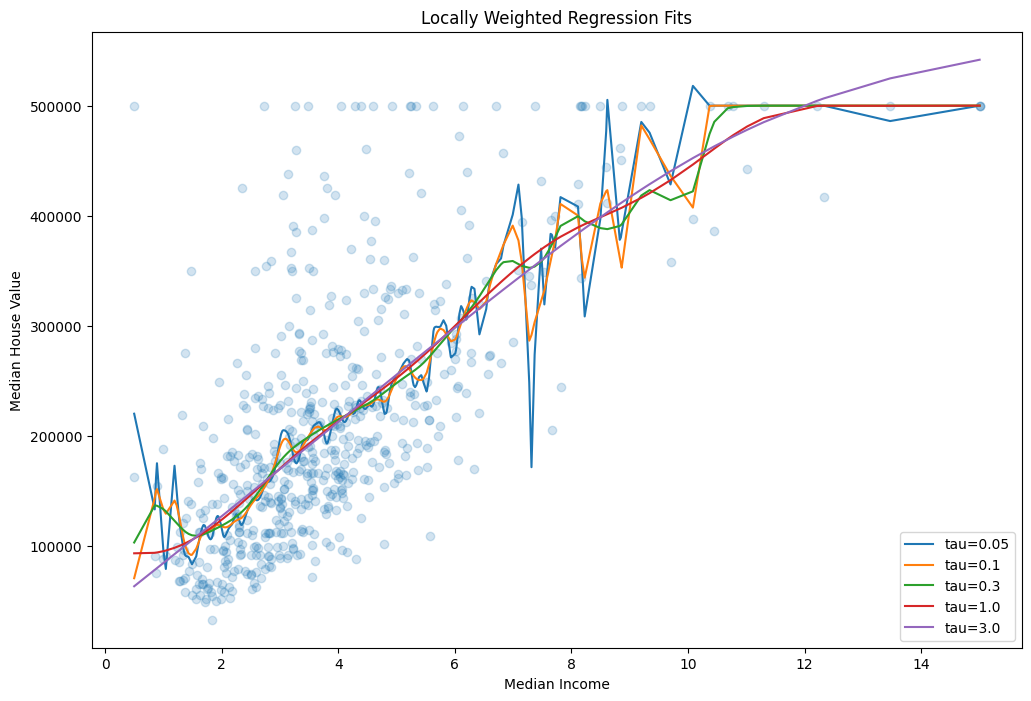

Best Tau: 0.3
OLS RMSE: 85304.41746282301
Best LWR RMSE: 83802.65314614441
Comparison Table:
  Model          RMSE
0   OLS  85304.417463
1   LWR  83802.653146
Applying LWR to all numerical features increases computational cost because a separate weighted regression must be solved for every query point.
As dimensionality increases, distances between points become less informative due to the curse of dimensionality.
Therefore, nearby points become harder to identify and the Gaussian kernel weights become less meaningful.


In [7]:
# Question 2.2: Locally Weighted Regression on Non-Linear Data

print("Locally Weighted Regression (LWR) is a non-parametric regression technique where a separate linear model is fitted around each query point. Instead of learning one global relationship, LWR assigns higher importance to nearby training samples using a Gaussian kernel. This makes it suitable for capturing non-linear relationships present in housing data.")
# Question 2.2

#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

#1. Load Dataset
df = pd.read_csv("2.2/housing.csv")
print(df.head())

#2. Select Required Feature and Target
X = df[["median_income"]]
y = df["median_house_value"]
#Randomly Sample 2000 Rows
sample_df = df.sample(n=2000,random_state=42)
X = sample_df[["median_income"]].values
y = sample_df["median_house_value"].values
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)
#3(c) Add Bias Column
X_train_bias = np.c_[np.ones(len(X_train)),X_train]
X_test_bias = np.c_[np.ones(len(X_test)),X_test]

#3(a) Implement Gaussian Kernel
def gaussian_kernel(x_train, x_query, tau):
    weights = np.exp(-(np.sum((x_train-x_query)**2, axis=1))/(2*tau**2))
    return weights
#3(b) Implement LWR From Scratch
def locally_weighted_regression(X_train,y_train,X_query,tau):
    predictions = []
    for xq in X_query:

        weights = gaussian_kernel(X_train[:,1:],xq[1:],tau)
        WX = X_train * weights[:,None]
        theta = np.linalg.pinv(X_train.T @ WX) @ (X_train.T @ (weights * y_train))
        prediction = xq @ theta
        predictions.append(prediction)
    return np.array(predictions)
#Test Different Bandwidth Values
taus = [0.05,0.1,0.3,1.0,3.0]
rmse_results = []

#4. Plot LWR Fits and Calculate RMSE
plt.figure(figsize=(12,8))
plt.scatter(X_test,y_test,alpha=0.2)
for tau in taus:
    y_pred = locally_weighted_regression(X_train_bias,y_train,X_test_bias,tau)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    rmse_results.append([tau,rmse])
    sorted_idx = np.argsort(X_test[:,0])
    plt.plot(X_test[sorted_idx],y_pred[sorted_idx],label=f"tau={tau}")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Locally Weighted Regression Fits")
plt.legend()
plt.show()
#RMSE Table
rmse_table = pd.DataFrame(rmse_results,columns=["Bandwidth Tau","Test RMSE"])
rmse_table
#Best bandwidth
best_tau = rmse_table.loc[rmse_table["Test RMSE"].idxmin(),"Bandwidth Tau"]
print("Best Tau:",best_tau)

#5. Ordinary Least Squares Comparison
ols = LinearRegression()
ols.fit(X_train,y_train)
ols_pred = ols.predict(X_test)
ols_rmse = np.sqrt(mean_squared_error(y_test,ols_pred))
print("OLS RMSE:",ols_rmse)
#6. Best LWR RMSE
best_lwr_rmse = rmse_table.loc[rmse_table["Bandwidth Tau"]==best_tau,"Test RMSE"].values[0]
print("Best LWR RMSE:",best_lwr_rmse)

#Final Comparison Table
comparison = pd.DataFrame({"Model":["OLS","LWR"],"RMSE":[ols_rmse,best_lwr_rmse]})
print("Comparison Table:")
print(comparison)

#7. Apply LWR to All Numeric Features
print("Applying LWR to all numerical features increases computational cost because a separate weighted regression must be solved for every query point.")
print("As dimensionality increases, distances between points become less informative due to the curse of dimensionality.")
print("Therefore, nearby points become harder to identify and the Gaussian kernel weights become less meaningful.")

The objective of this task is to build an ensemble-based fraud detection model using Random Forest. Since fraudulent transactions are rare compared to normal transactions, the model must handle class imbalance carefully. Random Forest is used because it reduces variance through bagging and provides feature importance scores for interpreting which variables contribute most to fraud detection.
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   

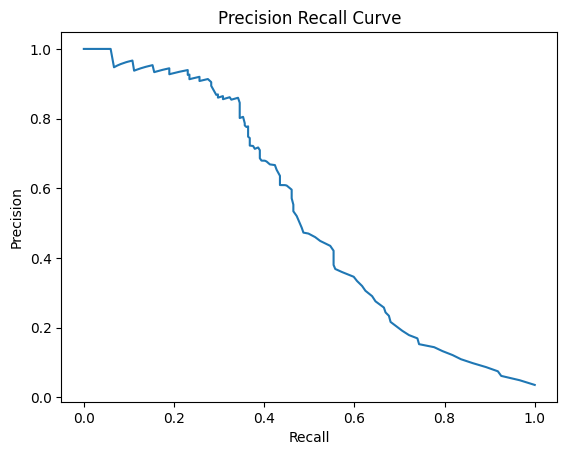

A high ROC-AUC indicates that the model can separate fraudulent and non-fraudulent transactions effectively.
Average Precision is especially important because the dataset is highly imbalanced and focuses on correctly identifying rare fraud cases.


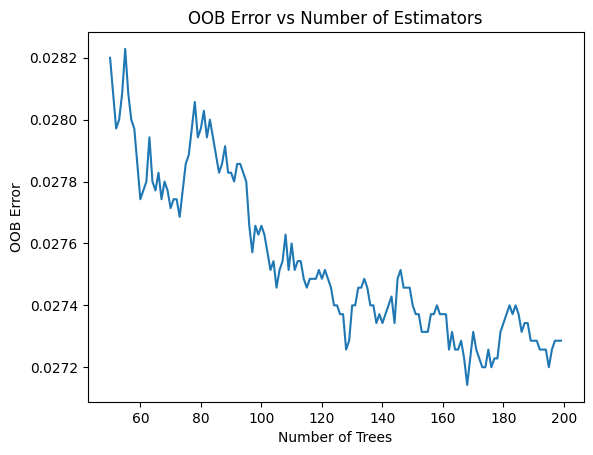

Initially, increasing the number of trees reduces OOB error because the ensemble becomes more stable.
After a certain point, the improvement becomes smaller, indicating diminishing returns.
The optimal number of trees is chosen where additional trees do not significantly improve performance.


In [8]:
# Question 3.1: Random Forest with Feature Importance for Fraud Detection

print("The objective of this task is to build an ensemble-based fraud detection model using Random Forest. Since fraudulent transactions are rare compared to normal transactions, the model must handle class imbalance carefully. Random Forest is used because it reduces variance through bagging and provides feature importance scores for interpreting which variables contribute most to fraud detection.")

#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split,GridSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report)
from sklearn.preprocessing import StandardScaler

#1. Load Dataset
df = pd.read_csv("3.1/train_transaction.csv")
print(df.head())
#Sample 50000 rows
df = df.sample(50000,random_state=42)
print("Data Loaded")

#2. Preprocessing
#(a) Drop >50% missing columns
missing = df.isnull().mean()
drop_cols = missing[missing > 0.5].index
df = df.drop(columns=drop_cols)
#(b) Encode categorical columns as integer codes
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].astype("category").cat.codes
#(c) Median imputation
df = df.fillna(df.median())

# Define X and y AFTER preprocessing
X = df.drop("isFraud",axis=1)
y = df["isFraud"]

#(d) Stratified 70/15/15 split
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.30,stratify=y,random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.50,stratify=y_temp,random_state=42)
print("Preprocessing over")

#3. Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200,oob_score=True,class_weight="balanced",random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)
print("OOB Score:",rf.oob_score_)
print("Random forest model built")

#4. Tune max_features
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
values = ["sqrt","log2",0.3,0.5]
for mf in values:
    model = RandomForestClassifier(n_estimators=200,max_features=mf,class_weight="balanced",random_state=42)
    scores = cross_val_score(model,X_train,y_train,cv=StratifiedKFold(5),scoring="roc_auc")
    print(mf,scores.mean())
print("Max features tuning over")

#5. Feature importance comparison
#(a) MDI
mdi = pd.DataFrame({"Feature":X.columns,"Importance":rf.feature_importances_})
mdi.sort_values("Importance",ascending=False).head(20)
#(b) Permutation Importance on validation set
from sklearn.inspection import permutation_importance
perm = permutation_importance(rf,X_val,y_val,scoring="roc_auc",random_state=42)
perm_df = pd.DataFrame({"Feature":X.columns,"Importance":perm.importances_mean})
perm_df.sort_values("Importance",ascending=False).head(20)
print("MDI may favour high-cardinality features because they create more possible splits.")
print("Permutation importance is usually more reliable because it directly measures the impact on validation performance.")

#6. Test evaluation
from sklearn.metrics import (roc_auc_score,average_precision_score,precision_recall_curve)
test_prob = rf.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test,test_prob)
ap = average_precision_score(y_test,test_prob)
print("AUC ROC:",auc)
print("Average Precision:",ap)
precision, recall, _ = precision_recall_curve(y_test,test_prob)
plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()
print("A high ROC-AUC indicates that the model can separate fraudulent and non-fraudulent transactions effectively.")
print("Average Precision is especially important because the dataset is highly imbalanced and focuses on correctly identifying rare fraud cases.")

#7. OOB error curve
errors=[]

for n in range(50,200):
    model = RandomForestClassifier(n_estimators=n,oob_score=True, class_weight="balanced",random_state=42)
    model.fit(X_train,y_train)
    errors.append(1-model.oob_score_)

plt.plot(range(50,200),errors)
plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("OOB Error vs Number of Estimators")
plt.show()
print("Initially, increasing the number of trees reduces OOB error because the ensemble becomes more stable.")
print("After a certain point, the improvement becomes smaller, indicating diminishing returns.")
print("The optimal number of trees is chosen where additional trees do not significantly improve performance.")


The objective of this task is to predict whether a stock will have a positive 21-day forward return using XGBoost. Time-based splitting is used to avoid look-ahead bias and preserve the chronological structure of financial data.
Dataset Shape: (619040, 7)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9880\3578931611.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[features] = df[features].astype(np.float32)


Shape After Feature Engineering: (608398, 14)

Train Period:
2013-03-12 00:00:00 to 2016-06-29 00:00:00

Validation Period:
2016-06-30 00:00:00 to 2016-12-30 00:00:00

Test Period:
2017-01-03 00:00:00 to 2018-02-07 00:00:00

Train Shape: (405654, 6)
Validation Shape: (63719, 6)
Test Shape: (139025, 6)

Starting Grid Search...

depth=3, lr=0.01, subsample=0.6, val_auc=0.52366
depth=3, lr=0.01, subsample=0.8, val_auc=0.52498
depth=3, lr=0.05, subsample=0.6, val_auc=0.52655
depth=3, lr=0.05, subsample=0.8, val_auc=0.52482
depth=3, lr=0.1, subsample=0.6, val_auc=0.52511
depth=3, lr=0.1, subsample=0.8, val_auc=0.52460
depth=5, lr=0.01, subsample=0.6, val_auc=0.52448
depth=5, lr=0.01, subsample=0.8, val_auc=0.52362
depth=5, lr=0.05, subsample=0.6, val_auc=0.52387
depth=5, lr=0.05, subsample=0.8, val_auc=0.52282
depth=5, lr=0.1, subsample=0.6, val_auc=0.52480
depth=5, lr=0.1, subsample=0.8, val_auc=0.52234
depth=7, lr=0.01, subsample=0.6, val_auc=0.52170
depth=7, lr=0.01, subsample=0.8, val_a

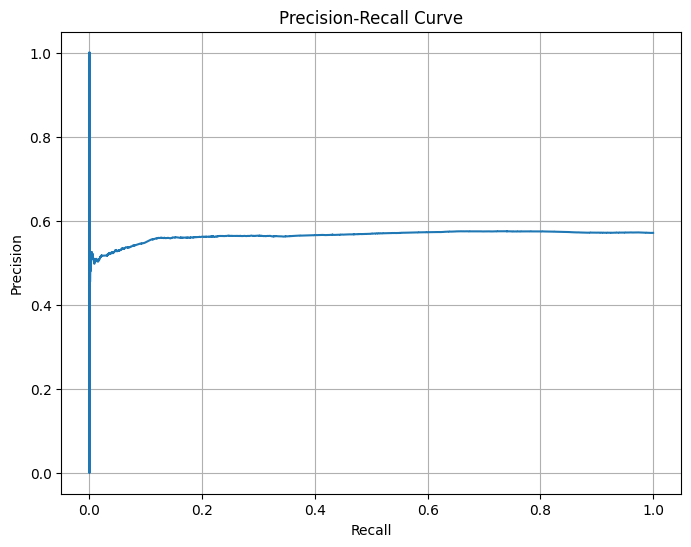

BASELINE PERFORMANCE
Baseline AUC-ROC: 0.5
Baseline AUC-PR: 0.57116

Improvement Over Baseline
AUC-ROC Improvement: -0.00154
AUC-PR Improvement: -0.00668

Feature Importances
              Feature  Importance
5              RSI_14    0.387127
3              vol_21    0.178548
2              ret_21    0.163849
1              ret_10    0.099160
0               ret_5    0.094963
4  volume_price_ratio    0.076352


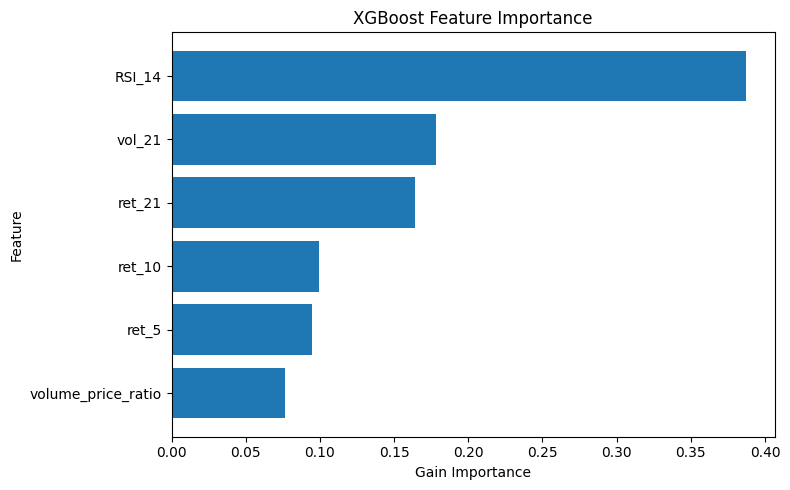


Economic Interpretation:
The most important feature is RSI_14. This feature captures information related to momentum, risk, or trading activity that helps distinguish future outperforming stocks from underperforming stocks.

Look-Ahead Bias Discussion:
Random k-fold cross-validation is invalid for financial time series because future observations can leak into the training set.
This gives the model access to information that would not have been available at the prediction date.
As a result, validation performance becomes overly optimistic and does not reflect real trading conditions.
Time-based train/validation/test splits preserve the chronological order of information arrival.
Look-ahead bias occurs when future information leaks into model training and artificially inflates model performance.
Therefore chronological validation is essential in quantitative finance.

Finance Context:
Evaluation Period:2017-01-03 to 2018-02-07
Train/Test Boundary: 2017-01-01
Potential Survivorship Bias

In [9]:
# Question 3.2: XGBoost for Stock Return Classification

print("The objective of this task is to predict whether a stock will have a positive 21-day forward return using XGBoost. Time-based splitting is used to avoid look-ahead bias and preserve the chronological structure of financial data.")

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    precision_recall_curve
)

# 1. Load Dataset
df = pd.read_csv("3.2/all_stocks_5yr.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["Name", "date"])
print("Dataset Shape:", df.shape)

# 2. Feature Engineering

# RSI Function
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))
g = df.groupby("Name")
# Returns
df["ret_5"] = g["close"].pct_change(5)
df["ret_10"] = g["close"].pct_change(10)
df["ret_21"] = g["close"].pct_change(21)
# Volatility
daily_ret = g["close"].pct_change()
df["vol_21"] = (daily_ret.groupby(df["Name"]).rolling(21).std().reset_index(level=0, drop=True))
# Volume Price Ratio
df["volume_price_ratio"] = df["volume"] / df["close"]
# RSI
df["RSI_14"] = g["close"].transform(lambda x: compute_rsi(x, 14))
# Target:
# Positive 21-Day Forward Return
forward_ret = g["close"].shift(-21) / df["close"] - 1
df["target"] = (forward_ret > 0).astype(int)
features = ["ret_5","ret_10","ret_21","vol_21","volume_price_ratio","RSI_14"]
df = df.dropna(subset=features + ["target"])
# Reduce memory usage
df[features] = df[features].astype(np.float32)
print("Shape After Feature Engineering:", df.shape)

# 3. Time-Based Split

train_df = df[df["date"] < "2017-01-01"].copy()
test_df = df[df["date"] >= "2017-01-01"].copy()
# Validation = Last 6 Months of Training Period
eval_start = train_df["date"].max() - pd.DateOffset(months=6)
train_main = train_df[train_df["date"] < eval_start]
eval_df = train_df[train_df["date"] >= eval_start]
X_train = train_main[features]
y_train = train_main["target"]
X_eval = eval_df[features]
y_eval = eval_df["target"]
X_test = test_df[features]
y_test = test_df["target"]
print("\nTrain Period:")
print(train_main["date"].min(), "to", train_main["date"].max())
print("\nValidation Period:")
print(eval_df["date"].min(), "to", eval_df["date"].max())
print("\nTest Period:")
print(test_df["date"].min(), "to", test_df["date"].max())
print("\nTrain Shape:", X_train.shape)
print("Validation Shape:", X_eval.shape)
print("Test Shape:", X_test.shape)

# 4. Hyperparameter Search

best_auc = -1
best_params = None
best_model = None
print("\nStarting Grid Search...\n")
for md in [3, 5, 7]:
    for lr in [0.01, 0.05, 0.1]:
        for ss in [0.6, 0.8]:
            model = XGBClassifier(
                max_depth=md,
                learning_rate=lr,
                subsample=ss,
                n_estimators=500,
                objective="binary:logistic",
                eval_metric="auc",
                random_state=42,
                tree_method="hist",
                n_jobs=-1,
                early_stopping_rounds=30
            )
            model.fit(X_train,y_train,eval_set=[(X_eval, y_eval)],verbose=False)
            pred = model.predict_proba(X_eval)[:, 1]
            auc = roc_auc_score(y_eval, pred)
            print(f"depth={md}, "f"lr={lr}, "f"subsample={ss}, "f"val_auc={auc:.5f}")
            if auc > best_auc:
                best_auc = auc
                best_params = {"max_depth": md,"learning_rate": lr,"subsample": ss}
                best_model = model
            gc.collect()
print("\nBest Parameters:")
print(best_params)
print("Best Validation AUC-ROC:", round(best_auc, 5))

# 5. Test Evaluation
test_prob = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_prob)
test_ap = average_precision_score(y_test, test_prob)
print("TEST SET PERFORMANCE")
print("Test AUC-ROC:", round(test_auc, 5))
print("Test Average Precision (AUC-PR):", round(test_ap, 5))

# Classification Report
test_pred = (test_prob >= 0.5).astype(int)
print("\nClassification Report")
print(classification_report(y_test, test_pred))

# Precision Recall Curve

precision, recall, _ = precision_recall_curve(y_test,test_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

# 6. Baseline Comparison

majority_class = y_train.mode()[0]
baseline_prob = np.full(len(y_test),majority_class,dtype=float)

baseline_auc = roc_auc_score(y_test,baseline_prob)
baseline_ap = average_precision_score(y_test,baseline_prob)
print("BASELINE PERFORMANCE")
print("Baseline AUC-ROC:", round(baseline_auc, 5))
print("Baseline AUC-PR:", round(baseline_ap, 5))
print("\nImprovement Over Baseline")

print("AUC-ROC Improvement:",round(test_auc - baseline_auc, 5))
print("AUC-PR Improvement:",round(test_ap - baseline_ap, 5))

# 7. Feature Importance Plot

importance = pd.DataFrame({"Feature": features,"Importance": best_model.feature_importances_})
importance = importance.sort_values("Importance",ascending=False)
print("\nFeature Importances")
print(importance)
plt.figure(figsize=(8, 5))
plt.barh(importance["Feature"][::-1],importance["Importance"][::-1])
plt.xlabel("Gain Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

# Economic Interpretation
top_feature = importance.iloc[0]["Feature"]
print("\nEconomic Interpretation:")
print(f"The most important feature is {top_feature}. "
    "This feature captures information related to momentum, "
    "risk, or trading activity that helps distinguish future "
    "outperforming stocks from underperforming stocks."
)

# 8. Look-Ahead Bias Discussion

print("\nLook-Ahead Bias Discussion:")
print("Random k-fold cross-validation is invalid for financial time series because future observations can leak into the training set.")
print("This gives the model access to information that would not have been available at the prediction date.")
print("As a result, validation performance becomes overly optimistic and does not reflect real trading conditions.")
print("Time-based train/validation/test splits preserve the chronological order of information arrival.")
print("Look-ahead bias occurs when future information leaks into model training and artificially inflates model performance.")
print("Therefore chronological validation is essential in quantitative finance.")

# Finance Context Required by Assignment

print("\nFinance Context:")
print("Evaluation Period:"
    f"{test_df['date'].min().date()} to "
    f"{test_df['date'].max().date()}")
print("Train/Test Boundary: 2017-01-01")
print(
    "Potential Survivorship Bias: "
    "The dataset contains stocks that remain in the historical record and may not fully account for delisted companies. "
    "This can introduce survivorship bias and slightly overstate real-world predictive performance.")

print("Connection to UAPOML: In uncertainty-aware allocation, predictions should not be used alone.")
print("The uncertainty (σᵢ) associated with each prediction can guide position sizing, with larger positions allocated to high-confidence predictions and smaller positions allocated to uncertain signals.")

This task empirically estimates the bias-variance trade-off using bootstrap resampling.
Five supervised learning models of varying complexity are compared using Bias², Variance and Test AUC-ROC.
Bootstrap sampling is used because the true data-generating distribution is unknown, allowing empirical estimation of prediction variability.

Dataset Shape: (768, 9)

First Five Rows
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3           

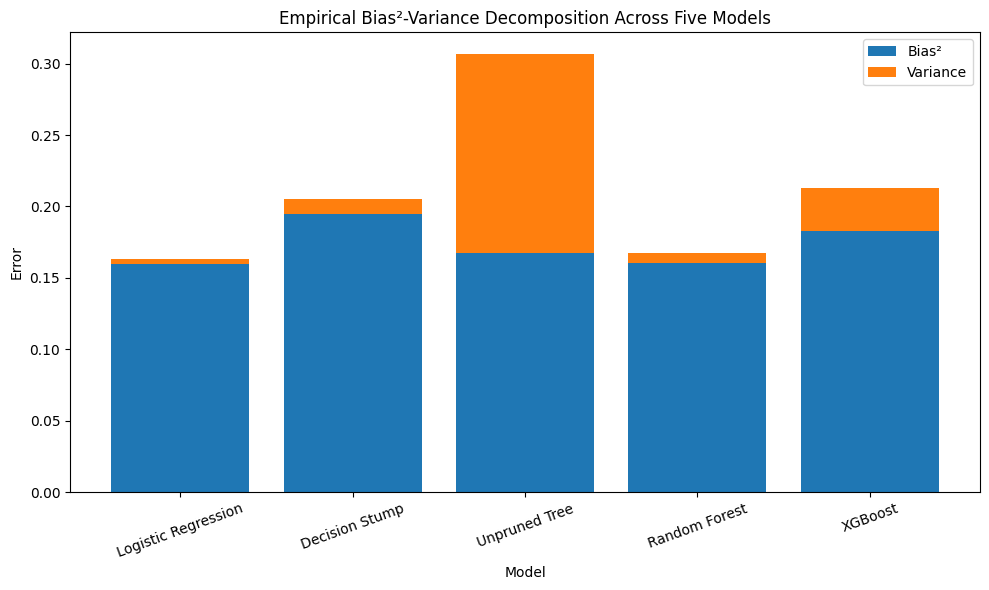

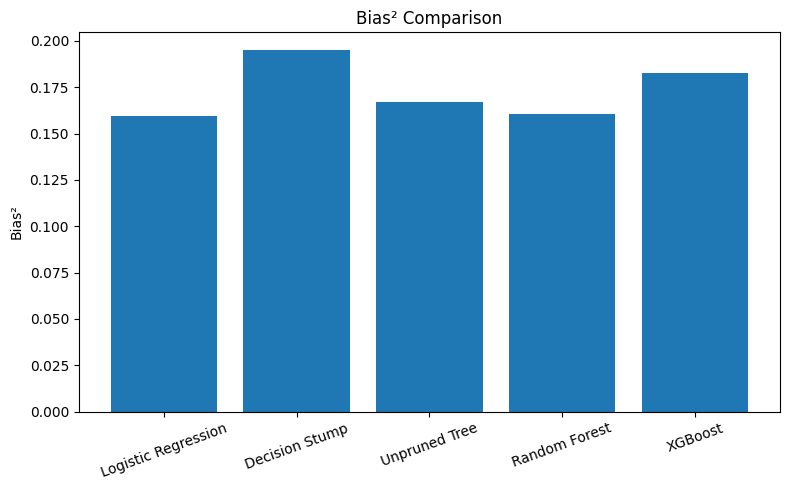

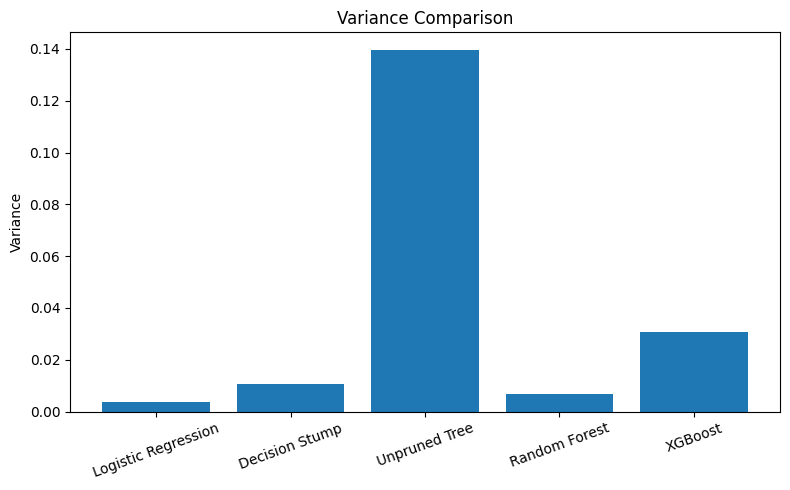



FINAL COMPARISON TABLE:
              Model    Bias²  Variance  Bias² + Variance  Test AUC-ROC
Logistic Regression 0.159715  0.003709          0.163424      0.836461
      Random Forest 0.160371  0.006766          0.167137      0.828971
     Decision Stump 0.194879  0.010658          0.205537      0.757942
            XGBoost 0.182563  0.030540          0.213103      0.818765
      Unpruned Tree 0.167171  0.139410          0.306580      0.811029

Interpretation:
The lowest Bias² is achieved by: Logistic Regression
The lowest Variance is achieved by: Logistic Regression
The highest Test AUC-ROC is achieved by: Logistic Regression
Simple models such as Logistic Regression generally exhibit higher bias because they cannot represent highly complex decision boundaries.
Decision Trees usually achieve low bias but high variance because small changes in the training data can substantially alter the tree structure.
Random Forest reduces variance by averaging predictions from many independentl

In [10]:

# Question 4.1: Empirical Bias-Variance Decomposition across Five Models

print("This task empirically estimates the bias-variance trade-off using bootstrap resampling.")
print("Five supervised learning models of varying complexity are compared using Bias², Variance and Test AUC-ROC.")
print("Bootstrap sampling is used because the true data-generating distribution is unknown, allowing empirical estimation of prediction variability.")

# Import Libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score,accuracy_score)

#1. Load Dataset

df = pd.read_csv("4/diabetes.csv")
print("\nDataset Shape:", df.shape)
print("\nFirst Five Rows")
print(df.head())
# Features and Target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

#2.Fixed 70/30 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)
print("\nTraining Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

#3. Bootstrap Parameters
B = 50
print("\nBootstrap Iterations :", B)
# Helper Function
def compute_bias_variance(predictions, y_true):
    predictions = np.asarray(predictions)
    mean_prediction = np.mean(predictions,axis=0)
    bias2 = np.mean((mean_prediction - y_true.values) ** 2)
    variance = np.mean(np.var(predictions,axis=0))
    return bias2, variance
# Bootstrap Evaluation Function
def bootstrap_model(model, X_train, y_train, X_test):
    probability_predictions = []
    for i in range(B):
        X_boot, y_boot = resample(X_train,y_train,replace=True,random_state=42 + i)
        model.fit(X_boot,y_boot)
        probs = model.predict_proba(X_test)[:, 1]
        probability_predictions.append(probs)
    return np.array(probability_predictions)
#4. Dictionary of Models
models = {"Logistic Regression":LogisticRegression(random_state=42,max_iter=1000),
    "Decision Stump":DecisionTreeClassifier(max_depth=1,random_state=42),
    "Unpruned Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(n_estimators=100,random_state=42),
    "XGBoost":XGBClassifier(random_state=42,eval_metric="logloss",use_label_encoder=False)}
# Containers
results = []
bias_values = []
variance_values = []
model_names = []

#5. Evaluate All Five Models using Bootstrap
for name, model in models.items():
    print("=" * 60)
    print("Evaluating:", name)
    # Bootstrap Predictions
    bootstrap_predictions = bootstrap_model(model,X_train,y_train,X_test)
    # Bias² and Variance
    bias2, variance = compute_bias_variance(bootstrap_predictions,y_test)
    # Average Prediction Across Bootstraps
    mean_prediction = np.mean(bootstrap_predictions,axis=0)
    # Test ROC-AUC
    auc = roc_auc_score(y_test,mean_prediction)
    # Store Results
    results.append([name,bias2,variance,bias2 + variance,auc])
    bias_values.append(bias2)
    variance_values.append(variance)
    model_names.append(name)
    # Display Results
    print(f"Bias²      : {bias2:.6f}")
    print(f"Variance   : {variance:.6f}")
    print(f"Bias²+Var  : {(bias2+variance):.6f}")
    print(f"Test AUC   : {auc:.6f}")
# Summary Table
summary = pd.DataFrame(results,columns=["Model","Bias²","Variance","Bias² + Variance","Test AUC-ROC"])
summary = summary.sort_values(by="Bias² + Variance")
print("\n")
print("SUMMARY TABLE")
print(summary)
# Best Model According to Bias² + Variance
best_model = summary.iloc[0]["Model"]
print("\nBest Model Based on Lowest Bias² + Variance:")
print(best_model)
# Best Model According to Test AUC
best_auc_model = summary.loc[summary["Test AUC-ROC"].idxmax(),"Model"]
print("\nBest Model Based on Test AUC-ROC:")
print(best_auc_model)

#6. Bias² and Variance Stacked Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(model_names,bias_values,label="Bias²")
plt.bar(model_names,variance_values,bottom=bias_values,label="Variance")
plt.xticks(rotation=20)
plt.ylabel("Error")
plt.xlabel("Model")
plt.title("Empirical Bias²-Variance Decomposition Across Five Models")
plt.legend()
plt.tight_layout()
plt.show()
# Individual Bias² Plot
plt.figure(figsize=(8,5))
plt.bar(model_names,bias_values)
plt.xticks(rotation=20)
plt.ylabel("Bias²")
plt.title("Bias² Comparison")
plt.tight_layout()
plt.show()
# Individual Variance Plot
plt.figure(figsize=(8,5))
plt.bar(model_names,variance_values)
plt.xticks(rotation=20)
plt.ylabel("Variance")
plt.title("Variance Comparison")
plt.tight_layout()
plt.show()
# Final Comparison Table
print("\n")
print("FINAL COMPARISON TABLE:")
print(summary.to_string(index=False))
#7. Interpretation
print("\nInterpretation:")
lowest_bias = summary.sort_values("Bias²").iloc[0]["Model"]
lowest_variance = summary.sort_values("Variance").iloc[0]["Model"]
highest_auc = summary.sort_values("Test AUC-ROC", ascending=False).iloc[0]["Model"]
print(f"The lowest Bias² is achieved by: {lowest_bias}")
print(f"The lowest Variance is achieved by: {lowest_variance}")
print(f"The highest Test AUC-ROC is achieved by: {highest_auc}")
print("Simple models such as Logistic Regression generally exhibit higher bias because they cannot represent highly complex decision boundaries.")
print("Decision Trees usually achieve low bias but high variance because small changes in the training data can substantially alter the tree structure.")
print("Random Forest reduces variance by averaging predictions from many independently trained trees.")
print("XGBoost sequentially corrects previous prediction errors and therefore reduces both bias and variance when appropriately regularized.")
print("Bagging reduces prediction variance by averaging many independently trained models.")
print("The variance of an ensemble is approximately ρσ² + ((1−ρ)/B)σ², where ρ is the correlation between base learners,σ² is the variance of an individual learner, and B is the number of models in the ensemble.")
print("As the number of trees increases, the second term decreases, causing overall ensemble variance to become smaller.")
print("Random Forest introduces feature randomness during tree construction, reducing the correlation (ρ) among trees and achieving a larger variance reduction than ordinary bagging.")
print("Boosting builds trees sequentially so that each new learner focuses on the mistakes made by previous learners.")
print("Consequently, boosting often reduces both bias and variance while maintaining strong predictive accuracy.")
print("The empirical Bias²-Variance decomposition observed above demonstrates the classical machine learning trade-off between model complexity, generalization performance, and predictive stability.")                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

The objective of this task is to predict whether the 21-day forward return of a NIFTY-50 stock will be positive using Gradient Boosting.
Time-series validation is adopted to preserve chronological ordering and avoid look-ahead bias.
Prediction uncertainty is estimated using bootstrap ensemble disagreement and applied to an illustrative portfolio construction exercise.
(270022, 8)
         Date      Open      High       Low     Close  Adj Close    Volume  \
0  2003-01-01  1.096683  1.115076  1.096683  1.106645   0.033884  404318.0   
1  2003-01-02  1.108178  1.111244  1.105113  1.109711   0.033978  407763.0   
2  2003-01-03  1.118907  1.125805  1.104346  1.110477   0.034002  410308.0   
3  2003-01-06  1.118907  1.118907  1.097449  1.102814   0.033767  404762.0   
4  2003-01-07  1.103580  1.111244  1.094383  1.105113   0.033837  407737.0   

        Symbol  
0  ADANIENT.NS  
1  ADANIENT.NS  
2  ADANIENT.NS  
3  ADANIENT.NS  
4  ADANIENT.NS  
Index(['Date', 'Open', 'High', 'Low', 'Close',

<Figure size 900x500 with 0 Axes>

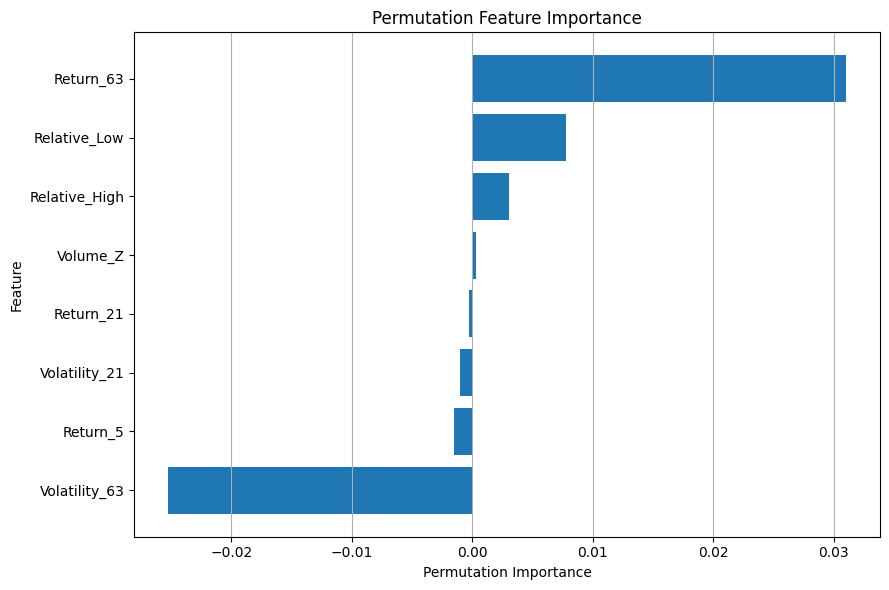


Top Five Features
['Return_63', 'Relative_Low', 'Relative_High', 'Volume_Z', 'Return_21']

Test AUC using Top Five Features
0.52219

AUC Comparison
                    Model  Test AUC-ROC
0      Full Feature Model      0.508922
1  Top Five Feature Model      0.522188

Training Bootstrap Ensemble:

Average Uncertainty : 0.02323


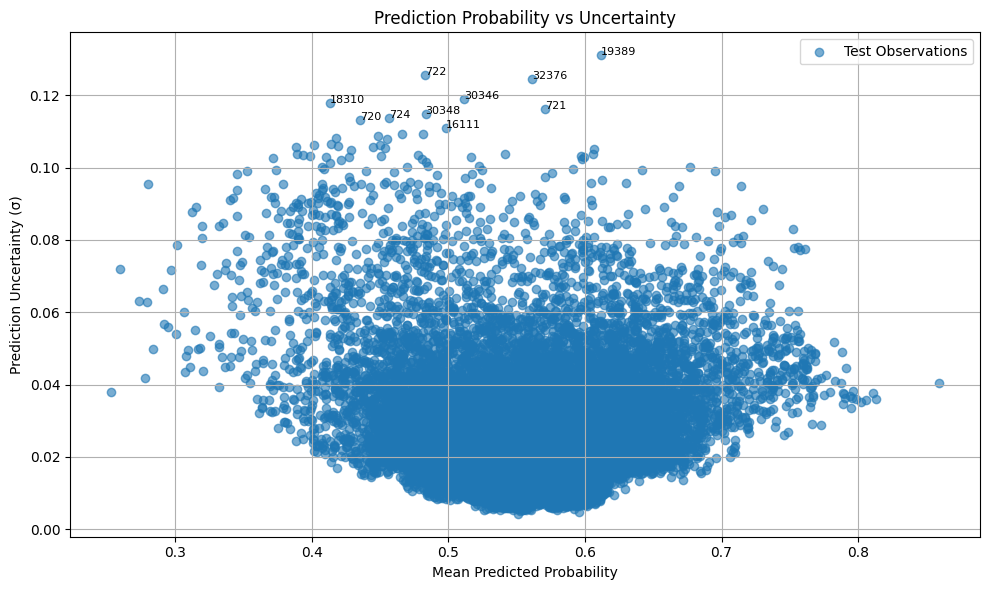

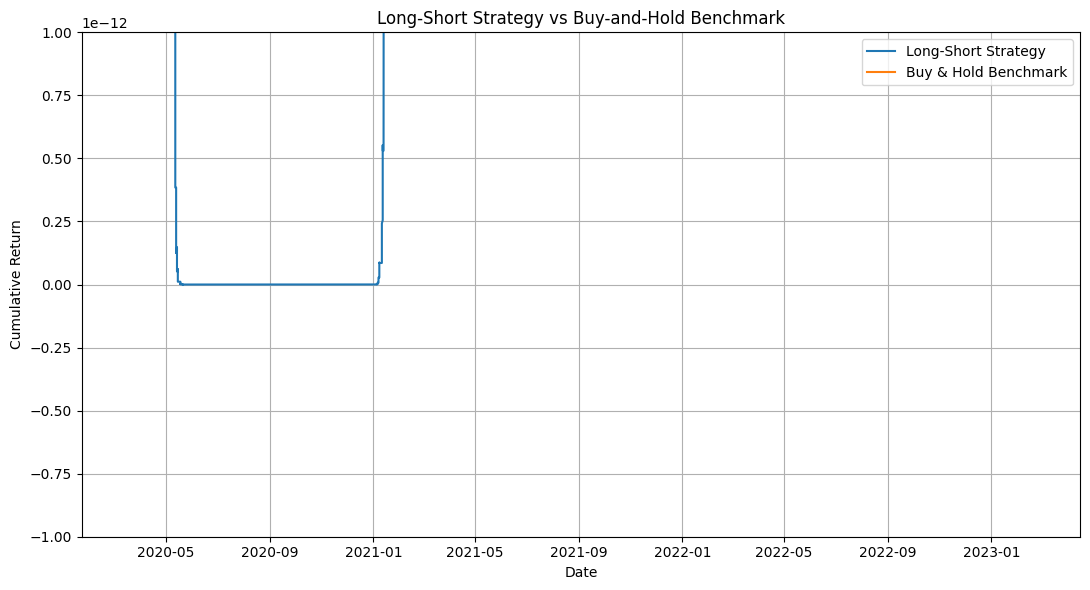


Performance Summary:
Full Feature Model Test AUC : 0.50892
Top Five Feature Model Test AUC : 0.52219
Average Prediction Uncertainty : 0.02323
Maximum Prediction Uncertainty : 0.13103
Minimum Prediction Uncertainty : 0.00429

Reflection:
Financial markets are highly non-stationary, meaning that relationships learned from historical data may not remain valid in the future. This makes overfitting a major risk because a model that performs well on past data may fail when market conditions change.
Look-ahead bias occurs when future information is unintentionally used during training or validation. Using expanding-window time-series validation prevents this leakage by ensuring that only past observations are available when making future predictions.
The long-short strategy shown here ignores transaction costs, bid-ask spreads, slippage and market impact. These practical considerations can substantially reduce realised returns even if the predictive model appears accurate.
Prediction uncerta

In [1]:
# Question 5.1: Gradient Boosting with Uncertainty Estimation
print("The objective of this task is to predict whether the 21-day forward return of a NIFTY-50 stock will be positive using Gradient Boosting.")
print("Time-series validation is adopted to preserve chronological ordering and avoid look-ahead bias.")
print("Prediction uncertainty is estimated using bootstrap ensemble disagreement and applied to an illustrative portfolio construction exercise.")
# Import Libraries
import warnings
warnings.filterwarnings("ignore")
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.utils import resample

# 1. Load Dataset

folder = "5"
files = glob.glob(os.path.join(folder, "*.csv"))
dataframes = []

for file in files:
    temp = pd.read_csv(file)
    symbol = os.path.splitext(os.path.basename(file))[0]
    temp["Symbol"] = symbol
    dataframes.append(temp)
df = pd.concat(dataframes, ignore_index=True)
print(df.shape)
print(df.head())
print(df.columns)

# Convert Date Column
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol","Date"])
df.reset_index(drop=True, inplace=True)

# 2. Feature Engineering
group = df.groupby("Symbol")
# Daily Return
daily_return = group["Close"].pct_change()
# (a) Rolling Returns
df["Return_5"] = group["Close"].pct_change(5)
df["Return_21"] = group["Close"].pct_change(21)
df["Return_63"] = group["Close"].pct_change(63)
# (b) Rolling Volatility
df["Volatility_21"] = (daily_return.groupby(df["Symbol"]).rolling(21).std().reset_index(level=0,drop=True))
df["Volatility_63"] = (daily_return.groupby(df["Symbol"]).rolling(63).std().reset_index(level=0,drop=True))
# (c) Price Relative to 52-week High
rolling_high = (group["Close"].rolling(252).max().reset_index(level=0,drop=True))
df["Relative_High"] = df["Close"] / rolling_high
# (d) Price Relative to 52-week Low
rolling_low = (group["Close"].rolling(252).min().reset_index(level=0,drop=True))
df["Relative_Low"] = df["Close"] / rolling_low
# (e) Volume Z-score
volume_mean = (group["Volume"].rolling(21).mean().reset_index(level=0,drop=True))
volume_std = (group["Volume"].rolling(21).std().reset_index(level=0,drop=True))
df["Volume_Z"] = (df["Volume"] - volume_mean) / volume_std
# Target Variable
forward_return = (group["Close"].shift(-21)/ df["Close"]- 1)
df["Target"] = (forward_return > 0).astype(int)
df["Forward_Return"] = forward_return
# Feature List
features = ["Return_5","Return_21","Return_63","Volatility_21","Volatility_63","Relative_High","Relative_Low","Volume_Z"]
df = df.dropna().reset_index(drop=True)
print("\nShape After Feature Engineering")
print(df.shape)
# Chronological Train-Test Split
split_date = df["Date"].quantile(0.80)
train_df = df[df["Date"] < split_date].copy()
test_df = df[df["Date"] >= split_date].copy()
print("\nTraining Samples :", len(train_df))
print("Testing Samples :", len(test_df))

print("\nTraining Period")
print(train_df["Date"].min(), "to", train_df["Date"].max())
print("\nTesting Period")
print(test_df["Date"].min(), "to", test_df["Date"].max())
# Training and Testing Data
X_train = train_df[features].astype(np.float32)
y_train = train_df["Target"]
X_test = test_df[features].astype(np.float32)
y_test = test_df["Target"]
# Expanding Window Cross Validation
tscv = TimeSeriesSplit(n_splits=3)
print("\nCreated Expanding Window TimeSeriesSplit")
# Hyperparameter Grid
n_estimators_grid = [100,200,500]
max_depth_grid = [2,3,5]
learning_rate_grid = [0.01,0.05,0.1]
best_auc = -np.inf
best_params = None
best_model = None
cv_results = []

# 3. Hyperparameter Tuning using Expanding Window CV
for n_est in n_estimators_grid:
    for depth in max_depth_grid:
        for lr in learning_rate_grid:
            fold_scores = []
            print("-"*70)
            print(f"n_estimators={n_est}, max_depth={depth}, learning_rate={lr}")
            # Expanding Window Validation
            for fold, (train_index, val_index) in enumerate(tscv.split(X_train), start=1):
                X_fold_train = X_train.iloc[train_index]
                X_fold_val = X_train.iloc[val_index]
                y_fold_train = y_train.iloc[train_index]
                y_fold_val = y_train.iloc[val_index]
                model = GradientBoostingClassifier(n_estimators=n_est,learning_rate=lr,max_depth=depth,random_state=42)
                model.fit(X_fold_train,y_fold_train)
                val_probability = model.predict_proba(X_fold_val)[:,1]
                fold_auc = roc_auc_score(y_fold_val,val_probability)
                fold_scores.append(fold_auc)
                print(f"Fold {fold} AUC = {fold_auc:.5f}")
            # Mean CV Score
            mean_auc = np.mean(fold_scores)
            cv_results.append({"n_estimators": n_est,"max_depth": depth,"learning_rate": lr,"Mean_AUC": mean_auc})
            print(f"Mean Validation AUC = {mean_auc:.5f}")
            # Store Best Model
            if mean_auc > best_auc:
                best_auc = mean_auc
                best_params = {"n_estimators": n_est,"max_depth": depth,"learning_rate": lr}
print("\n")
print("GRID SEARCH COMPLETED")
best_model = GradientBoostingClassifier(n_estimators=best_params["n_estimators"],learning_rate=best_params["learning_rate"],max_depth=best_params["max_depth"],random_state=42)
best_model.fit(X_train, y_train)

cv_table = pd.DataFrame(cv_results)
cv_table = cv_table.sort_values(by="Mean_AUC",ascending=False)
print("\nGrid Search Results")
cv_table.to_csv("GradientBoosting_CV_Results.csv",index=False)
print("\nBest Parameters")
print(best_params)
print("\nBest Validation AUC")
print(round(best_auc,5))

# 4. Train Final Model
best_model = GradientBoostingClassifier(n_estimators=best_params["n_estimators"],max_depth=best_params["max_depth"],learning_rate=best_params["learning_rate"],random_state=42)
best_model.fit(X_train,y_train)
print("\nBest Gradient Boosting Model Trained.")
# Test Set Evaluation
test_probability = best_model.predict_proba(X_test)[:,1]
test_auc = roc_auc_score(y_test,test_probability)
print("\nTest AUC-ROC (Full Feature Model):")
print(round(test_auc,5))

# 5. Permutation Importance
print("\nComputing Permutation Importance:")
perm = permutation_importance(estimator=best_model,X=X_test,y=y_test,scoring="roc_auc",n_repeats=10,random_state=42,n_jobs=-1)
importance = pd.DataFrame({"Feature":features,"Importance":perm.importances_mean})
importance = importance.sort_values(by="Importance",ascending=False)
print("\nPermutation Importance")
print(importance)
# Plot Permutation Importance
plt.figure(figsize=(9,5))
plt.figure(figsize=(9,6))
plt.barh(importance["Feature"],importance["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")
plt.grid(axis="x")
plt.tight_layout()
plt.show()
# Top Five Features
top_features = importance.head(5)["Feature"].tolist()
print("\nTop Five Features")
print(top_features)
# Retrain using Top Five Features
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]
top_model = GradientBoostingClassifier(n_estimators=best_params["n_estimators"],max_depth=best_params["max_depth"],learning_rate=best_params["learning_rate"],random_state=42)
top_model.fit(X_train_top,y_train)
top_probability = top_model.predict_proba(X_test_top)[:,1]
top_auc = roc_auc_score(y_test,top_probability)
print("\nTest AUC using Top Five Features")
print(round(top_auc,5))
# AUC Comparison
comparison = pd.DataFrame({"Model":["Full Feature Model","Top Five Feature Model"],"Test AUC-ROC":[test_auc,top_auc]})
print("\nAUC Comparison")
print(comparison)

# 6. Uncertainty Estimation using Bootstrap Ensemble
print("\nTraining Bootstrap Ensemble:")
M = 30
ensemble_predictions = []
for i in range(M):
    X_boot, y_boot = resample(X_train,y_train,replace=True,random_state=42+i)
    model = GradientBoostingClassifier(n_estimators=best_params["n_estimators"],max_depth=best_params["max_depth"],learning_rate=best_params["learning_rate"],random_state=42+i)
    model.fit(X_boot,y_boot)
    prob = model.predict_proba(X_test)[:,1]
    ensemble_predictions.append(prob)
ensemble_predictions = np.array(ensemble_predictions)

# Mean Probability and Uncertainty
mean_probability = ensemble_predictions.mean(axis=0)
uncertainty = ensemble_predictions.std(axis=0)
print("\nAverage Uncertainty :",round(uncertainty.mean(),5))

# Scatter Plot
plt.figure(figsize=(10,6))
plt.scatter(mean_probability,uncertainty,alpha=0.6,label="Test Observations")
highest_uncertainty = np.argsort(uncertainty)[-10:]

for idx in highest_uncertainty:
    plt.annotate(str(idx),(mean_probability[idx],uncertainty[idx]),fontsize=8)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Prediction Uncertainty (σ)")
plt.title("Prediction Probability vs Uncertainty")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 7. Long-Short Portfolio Construction
portfolio = test_df.copy()
portfolio["Probability"] = mean_probability
portfolio["Uncertainty"] = uncertainty
portfolio = portfolio.sort_values(["Probability", "Uncertainty"],ascending=[False, True])
n = max(1,int(len(portfolio)*0.10))
portfolio["Signal"] = 0
portfolio.iloc[:n,portfolio.columns.get_loc("Signal")] = 1
portfolio.iloc[-n:,portfolio.columns.get_loc("Signal")] = -1
portfolio["Strategy_Return"] = (portfolio["Signal"]*portfolio["Forward_Return"])
portfolio["Benchmark_Return"] = portfolio["Forward_Return"]
portfolio = portfolio.sort_values("Date")
portfolio["Strategy_Cumulative"] = (1+portfolio["Strategy_Return"]).cumprod()
portfolio["Benchmark_Cumulative"] = (1+portfolio["Benchmark_Return"]).cumprod()
plt.figure(figsize=(11,6))
plt.plot(portfolio["Date"],portfolio["Strategy_Cumulative"],label="Long-Short Strategy")
plt.plot(portfolio["Date"],portfolio["Benchmark_Cumulative"],label="Buy & Hold Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Long-Short Strategy vs Buy-and-Hold Benchmark")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nPerformance Summary:")
print("Full Feature Model Test AUC :",round(test_auc,5))
print("Top Five Feature Model Test AUC :",round(top_auc,5))
print("Average Prediction Uncertainty :",round(uncertainty.mean(),5))
print("Maximum Prediction Uncertainty :",round(uncertainty.max(),5))
print("Minimum Prediction Uncertainty :",round(uncertainty.min(),5))

# Reflection
print("\nReflection:")
print("Financial markets are highly non-stationary, meaning that relationships learned from historical data may not remain valid in the future. This makes overfitting a major risk because a model that performs well on past data may fail when market conditions change.")
print("Look-ahead bias occurs when future information is unintentionally used during training or validation. Using expanding-window time-series validation prevents this leakage by ensuring that only past observations are available when making future predictions.")
print("The long-short strategy shown here ignores transaction costs, bid-ask spreads, slippage and market impact. These practical considerations can substantially reduce realised returns even if the predictive model appears accurate.")
print("Prediction uncertainty, represented by σ, provides valuable information for portfolio construction. Positions with high uncertainty should generally receive smaller allocations, whereas predictions with lower uncertainty may justify larger allocations within a risk-controlled portfolio.")
print("Combining predicted return probabilities with uncertainty estimates allows portfolio decisions to consider both expected return and confidence, supporting uncertainty-aware allocation as emphasised in quantitative finance.")
print("Finally, this exercise is purely illustrative and should not be interpreted as an investment recommendation because many real-world factors have been intentionally omitted.")


The objective of this task is to build a stacked ensemble for Titanic survival prediction.
Five diverse base learners are first trained using Out-of-Fold (OOF) predictions.
A Logistic Regression meta-learner is then trained on the OOF predictions to improve generalisation performance.



Training Shape: (891, 12)
Testing Shape: (418, 11)

Training Columns
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Training Samples : 891
Testing Samples  : 418

Feature Matrix Shape
(891, 5)

Base Learners
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- KNN

Created 5-Fold Stratified Cross Validation

OOF Prediction Matrix Shape : (891, 5)
Test Meta Feature Matrix Shape : (418, 5)

Logistic Regression
Fold 1 AUC = 0.87108
Fold 2 AUC = 0.84318
Fold 3 AUC = 0.82540
Fold 4 AUC = 0.82286
Fold 5 AUC = 0.87741
Overall OOF Accuracy : 0.78563
Overall OOF AUC : 0.84626

Decision Tree
Fold 1 AUC = 0.82101
Fold 2 AUC = 0.88068
Fold 3 AUC = 0.81517
Fold 4 AUC = 0.83951
Fold 5 AUC = 0.83872
Overall OOF Accuracy : 0.81369
Overall OOF AUC : 0.83213

Random Forest
Fold 1 AUC = 0.91653
Fold 2 AUC = 0.88884
Fold 3 AUC = 0.85067
Fold 4 AUC = 0.85963
Fold 5 AUC = 0.89735
Overall 

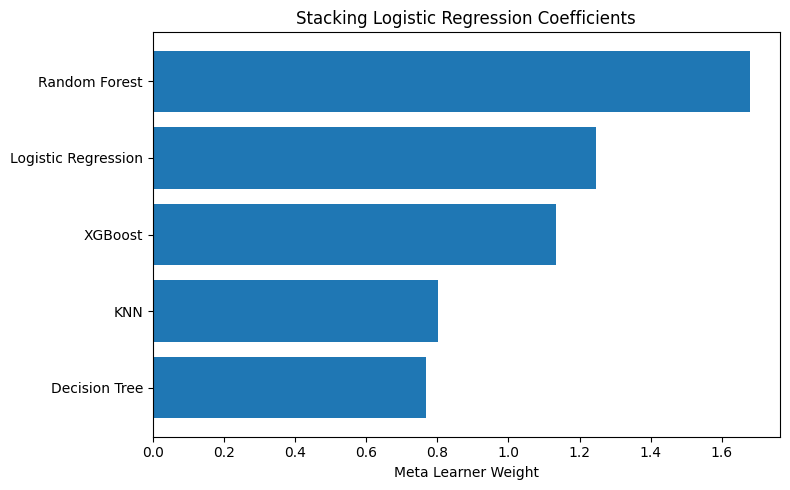


Highest Weighted Base Learner
Random Forest

Discussion:
The meta learner assigns larger weights to models that consistently provide useful probability estimates.
If the model with the highest coefficient also has the highest individual AUC-ROC, the stacking procedure agrees with the individual model rankings.
If a weaker individual model receives a large weight, it indicates that it contributes complementary information that improves ensemble diversity.

Submission file created successfully.
Filename : Titanic_Stacking_Submission.csv
Upload this file to the Kaggle Titanic competition and report the Public Leaderboard score in your assignment.


Out-of-fold predictions ensure that every training prediction is produced by a model that has never seen that observation during training.
This prevents information leakage between the base learners and the meta learner.
If in-sample predictions were used instead, the base learners would produce unrealistically accurate predictions on the trai

In [2]:

# Bonus Question: Stacked Generalisation for Titanic Survival Prediction

print("The objective of this task is to build a stacked ensemble for Titanic survival prediction.")
print("Five diverse base learners are first trained using Out-of-Fold (OOF) predictions.")
print("A Logistic Regression meta-learner is then trained on the OOF predictions to improve generalisation performance.")

# Import Libraries

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

# 1. Load Dataset
train_df = pd.read_csv("Bonus/Titanic_train.csv")
test_df  = pd.read_csv("Bonus/Titanic_test.csv")
print("\nTraining Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)
print("\nTraining Columns")
print(train_df.columns)
# Store Passenger IDs
test_passenger_id = test_df["PassengerId"]

# 2. Feature Engineering
features = ["Pclass","Sex","Age","Fare","Embarked"]
target = "Survived"
# Combine for identical preprocessing
combined = pd.concat([train_df[features],test_df[features]],axis=0,ignore_index=True)
# Encode Sex
combined["Sex"] = LabelEncoder().fit_transform(combined["Sex"])
# Encode Embarked
combined["Embarked"] = combined["Embarked"].fillna("Missing")
combined["Embarked"] = LabelEncoder().fit_transform(combined["Embarked"])
# Median Imputation
imputer = SimpleImputer(strategy="median")
combined = pd.DataFrame(imputer.fit_transform(combined),columns=features)
# Split Back
X_train = combined.iloc[:len(train_df)].copy()
X_test = combined.iloc[len(train_df):].copy()
y_train = train_df[target]
print("\nTraining Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
# Standardisation
numeric_features = ["Age","Fare"]
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])
print("\nFeature Matrix Shape")
print(X_train.shape)

# 3. Define Base Learners
base_models = {"Logistic Regression":LogisticRegression(random_state=42,max_iter=1000),
    "Decision Tree":DecisionTreeClassifier(max_depth=5,random_state=42),
    "Random Forest":RandomForestClassifier(n_estimators=100,random_state=42),
    "XGBoost":XGBClassifier(n_estimators=100,random_state=42,eval_metric="logloss"),
    "KNN":KNeighborsClassifier(n_neighbors=5)}
print("\nBase Learners")
for name in base_models:
    print("-", name)

# 4. Prepare Out-of-Fold Validation
kfold = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
print("\nCreated 5-Fold Stratified Cross Validation")
# Meta Feature Matrices
oof_predictions = np.zeros((len(X_train),len(base_models)))
test_predictions = np.zeros((len(X_test),len(base_models)))
print("\nOOF Prediction Matrix Shape :", oof_predictions.shape)
print("Test Meta Feature Matrix Shape :", test_predictions.shape)

# Train each base learner using OOF predictions
base_results = []
for model_index, (name, model) in enumerate(base_models.items()):
    print("\n" + "="*70)
    print(name)
    print("="*70)
    test_fold_predictions = np.zeros((len(X_test),5))
    for fold,(train_index,val_index) in enumerate(kfold.split(X_train,y_train),1):
        X_fold_train = X_train.iloc[train_index]
        y_fold_train = y_train.iloc[train_index]
        X_fold_val = X_train.iloc[val_index]
        y_fold_val = y_train.iloc[val_index]
        model.fit(X_fold_train,y_fold_train)
        val_probability = model.predict_proba(X_fold_val)[:,1]
        oof_predictions[val_index,model_index] = val_probability
        test_fold_predictions[:,fold-1] = model.predict_proba(X_test)[:,1]
        fold_auc = roc_auc_score(y_fold_val,val_probability)
        print(f"Fold {fold} AUC = {fold_auc:.5f}")
    # Average prediction over folds
    test_predictions[:,model_index] = test_fold_predictions.mean(axis=1)
    # Overall OOF Performance
    oof_auc = roc_auc_score(y_train,oof_predictions[:,model_index])
    oof_accuracy = accuracy_score(y_train,(oof_predictions[:,model_index]>=0.5).astype(int))
    base_results.append({"Model":name,"Accuracy":oof_accuracy,"AUC_ROC":oof_auc})
    print("Overall OOF Accuracy :",round(oof_accuracy,5))
    print("Overall OOF AUC :",round(oof_auc,5))
# Train Meta Learner
print("\n")
print("="*70)
print("Training Logistic Regression Meta Learner")
print("="*70)
meta_model = LogisticRegression(max_iter=1000,random_state=42)
meta_model.fit(oof_predictions,y_train)
stack_probability = meta_model.predict_proba(test_predictions)[:,1]
stack_prediction = (stack_probability>=0.5).astype(int)

stack_train_probability = meta_model.predict_proba(oof_predictions)[:,1]
stack_auc = roc_auc_score(y_train,stack_train_probability)
stack_accuracy = accuracy_score(y_train,(stack_train_probability>=0.5).astype(int))
base_results.append({"Model":"Stacked Ensemble","Accuracy":stack_accuracy,"AUC_ROC":stack_auc})
comparison = pd.DataFrame(base_results)
comparison = comparison.sort_values("AUC_ROC",ascending=False)
print("\n")
print("="*70)
print("Comparison Table")
print("="*70)
print(comparison)

# Meta Learner Coefficients
coef = pd.DataFrame({"Base Learner":list(base_models.keys()),"Coefficient":meta_model.coef_[0]})
coef = coef.sort_values("Coefficient",ascending=False)
print("\nMeta Learner Coefficients")
print(coef)
plt.figure(figsize=(8,5))
plt.barh(coef["Base Learner"],coef["Coefficient"])
plt.gca().invert_yaxis()
plt.xlabel("Meta Learner Weight")
plt.title("Stacking Logistic Regression Coefficients")
plt.tight_layout()
plt.show()
print("\nHighest Weighted Base Learner")
print(coef.iloc[0]["Base Learner"])
print("\nDiscussion:")
print("The meta learner assigns larger weights to models that consistently provide useful probability estimates.")
print("If the model with the highest coefficient also has the highest individual AUC-ROC, the stacking procedure agrees with the individual model rankings.")
print("If a weaker individual model receives a large weight, it indicates that it contributes complementary information that improves ensemble diversity.")
submission = pd.DataFrame({"PassengerId":test_passenger_id,"Survived":stack_prediction})
submission.to_csv("Titanic_Stacking_Submission.csv",index=False)
print("\nSubmission file created successfully.")
print("Filename : Titanic_Stacking_Submission.csv")
print("Upload this file to the Kaggle Titanic competition and report the Public Leaderboard score in your assignment.")
# Discussion
print("\n")
print("Out-of-fold predictions ensure that every training prediction is produced by a model that has never seen that observation during training.")
print("This prevents information leakage between the base learners and the meta learner.")
print("If in-sample predictions were used instead, the base learners would produce unrealistically accurate predictions on the training data because they have already memorised many of the samples.")
print("The meta learner would therefore learn from overly optimistic predictions rather than realistic generalisation performance.")
print("As a consequence, the stacked model would severely overfit and its performance on unseen test data would deteriorate.")
print("Out-of-fold predictions provide an unbiased estimate of each base learner's predictive capability and therefore produce a more reliable stacked ensemble.")
print("This approach is the standard methodology used in stacked generalisation.")
